# 3.2 — Derivative Rules, at the computer

Do the **pen-and-paper worksheet first**. Here `sympy` referees your answers, the nudge machine
gives a second opinion, and you'll watch $e^x$ perform its party trick.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def derivative(f, x, h=1e-6):        # the nudge machine from 3.1 — referee #2
    return (f(x + h) - f(x)) / h

## 1. sympy — the symbolic referee

`sp.diff(expression, x)` plays the exact rules from the lesson, perfectly, every time.
Use it to **check** pen work, never to skip it.

In [2]:
x = sp.symbols("x")

print(sp.diff(x**5, x))                    # power rule
print(sp.diff(3*x**4 - 5*x + 7, x))        # the lesson's worked example
print(sp.diff(sp.exp(x), x))               # e^x — its own derivative
print(sp.diff(sp.log(x), x))               # sympy's log IS ln

5*x**4
12*x**3 - 5
exp(x)
1/x


In [3]:
# YOUR TURN — referee your worksheet Part B answers (problems 6–12).
# Problem 6 is set up; add the rest. For 11 and 12 remember: 1/x is x**(-1), sqrt is x**sp.Rational(1,2).

print("P6:", sp.diff(x**3 + x**2, x))

# P7: 4x² - 9x + 2
# P8: x⁶/2 - 10x
# P9: 5e^x + 2 ln x
# P11: 1/x
# P12: sqrt(x)

P6: 3*x**2 + 2*x


## 2. Two referees must agree

The rules aren't magic — they're the nudge computation done once, in general. So the symbolic
answer and the numerical nudge must match at every point. Let's put that to the test on
$f(x) = 4x^2 - 9x + 2$ (your problem 7):

In [4]:
def f(x):
    return 4*x**2 - 9*x + 2

rule_answer = sp.diff(4*x**2 - 9*x + 2, x)     # what the rules say: 8x - 9
print("rules say f'(x) =", rule_answer)

for point in [-2, 0, 1, 3]:
    by_rule  = rule_answer.subs(x, point)       # .subs plugs a number into a symbol
    by_nudge = derivative(f, point)
    print(f"at x={point:>2}:  rule = {by_rule},  nudge ≈ {by_nudge:.4f}")

rules say f'(x) = 8*x - 9
at x=-2:  rule = -25,  nudge ≈ -25.0000
at x= 0:  rule = -9,  nudge ≈ -9.0000
at x= 1:  rule = -1,  nudge ≈ -1.0000
at x= 3:  rule = 15,  nudge ≈ 15.0000


## 3. 🌀 The celebrity: $e^x$ is its own derivative

Plot $e^x$ and its *measured* slope on the same axes. Most functions' slopes trace out some
different curve (you saw $x^2 \to 2x$, $\sin \to \cos$). One function in the universe traces
out **itself**:

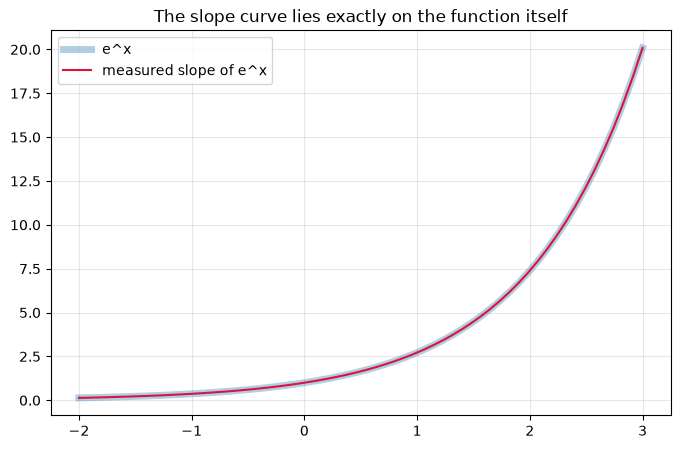

In [5]:
xs = np.linspace(-2, 3, 60)
measured = [derivative(np.exp, v) for v in xs]

plt.figure(figsize=(8, 5))
plt.plot(xs, np.exp(xs), linewidth=5, alpha=0.35, label="e^x")
plt.plot(xs, measured, color="crimson", linewidth=1.5, label="measured slope of e^x")
plt.grid(alpha=0.3)
plt.legend()
plt.title("The slope curve lies exactly on the function itself")
plt.show()

Growth rate = current value, everywhere. That's why $e$ runs compound interest, population
growth, radioactive decay — and why $e$ appears in softmax, cross-entropy and every
learning-rate schedule you'll ever read.

One more experiment for the lesson's deep-end question:

In [6]:
# YOUR TURN — deep-end verdict. Is 5·e^x its own derivative? Is e^x + 1?
print("d/dx of 5e^x    =", sp.diff(5*sp.exp(x), x))
print("d/dx of e^x + 1 =", sp.diff(sp.exp(x) + 1, x))

# Write your one-sentence explanation of WHY here as a comment:
# ...

d/dx of 5e^x    = 5*exp(x)
d/dx of e^x + 1 = exp(x)


---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude.
Next: 3.3 — the chain rule, aka the actual math of backpropagation.*